# Import Libraries

In [15]:
import os
import random
import torch
import torchvision.models as models
import torchvision.transforms as transforms
from PIL import Image
import matplotlib.pyplot as plt
import urllib.request
import json
import torch.nn as nn


# Load Pre-trained VGG16 in Evaluation Mode

In [4]:
vgg16 = models.vgg16(pretrained=True)
vgg16.eval()

c:\Users\Vivek Tiwari\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\Vivek Tiwari\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): ReLU(inplace=True)
    (16): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1

Download and load ImageNet class labels

In [5]:
url = "https://raw.githubusercontent.com/raghakot/keras-vis/master/resources/imagenet_class_index.json"
urllib.request.urlretrieve(url, "imagenet_class_index.json")

with open("imagenet_class_index.json", "r") as f:
    imagenet_labels = json.load(f)

Create a simple dictionary

In [ ]:
idx_to_label = {int(key): value[1] for key, value in imagenet_labels.items()}

Standard ImageNet Preprocessing Transforms

In [ ]:
preprocess = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

# Predict and Compare Classes

In [8]:
dataset_dir = 'CUB_200_2011/images/'

Select 8 random classes (folders)

In [11]:
all_classes = sorted(os.listdir(dataset_dir))

Filter out any hidden files

In [12]:
all_classes = [c for c in all_classes if os.path.isdir(os.path.join(dataset_dir, c))]

Reproducibility

In [13]:
random.seed(21) 
selected_classes = random.sample(all_classes, 8)

Visualize

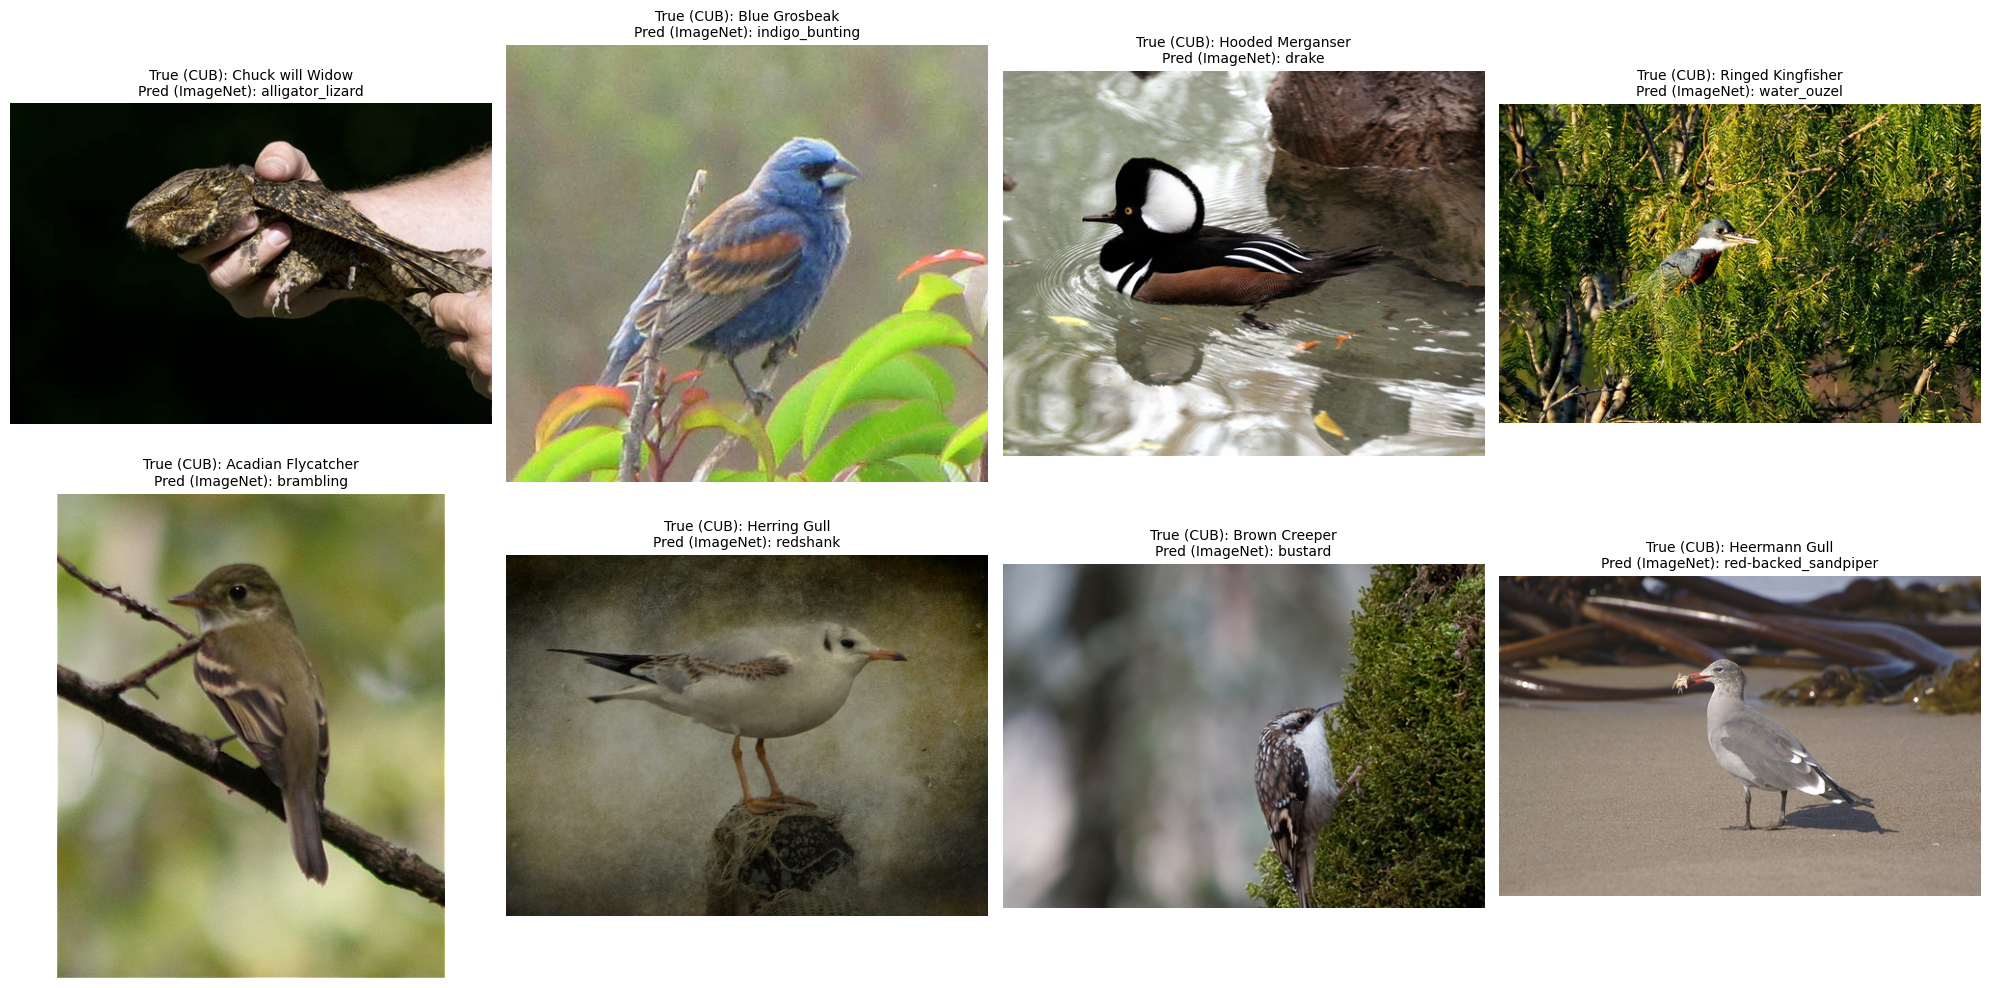

In [ ]:
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for i, cub_class in enumerate(selected_classes):
    class_dir = os.path.join(dataset_dir, cub_class)
    images_in_class = [img for img in os.listdir(class_dir) if img.endswith('.jpg')]
    
    # 2. Pick one random image from this class
    selected_image_name = random.choice(images_in_class)
    image_path = os.path.join(class_dir, selected_image_name)
    
    # Load and preprocess
    img = Image.open(image_path).convert('RGB')
    input_tensor = preprocess(img)
    input_batch = input_tensor.unsqueeze(0) # Add batch dimension
    
    # 3. Predict using VGG16
    with torch.no_grad():
        output = vgg16(input_batch)
    
    # Get the index of the highest predicted probability
    _, predicted_idx = torch.max(output, 1)
    predicted_imagenet_label = idx_to_label[predicted_idx.item()]
    
    # Clean up the CUB class name for display (e.g., '001.Black_footed_Albatross' -> 'Black footed Albatross')
    clean_cub_class = cub_class.split('.')[1].replace('_', ' ')
    
    # 4. Visualize
    axes[i].imshow(img)
    axes[i].axis('off')
    axes[i].set_title(f"True (CUB): {clean_cub_class}\nPred (ImageNet): {predicted_imagenet_label}", 
                      fontsize=10, color='blue' if clean_cub_class.lower() in predicted_imagenet_label.lower() else 'black')

plt.tight_layout()
plt.show()

# Reconfiguring the Output Layer

Inspect the original classifier

In [16]:
print("--- Original VGG16 Classifier ---")
print(vgg16.classifier)
print("\nNotice the last layer: (6): Linear(in_features=4096, out_features=1000, bias=True)")

--- Original VGG16 Classifier ---
Sequential(
  (0): Linear(in_features=25088, out_features=4096, bias=True)
  (1): ReLU(inplace=True)
  (2): Dropout(p=0.5, inplace=False)
  (3): Linear(in_features=4096, out_features=4096, bias=True)
  (4): ReLU(inplace=True)
  (5): Dropout(p=0.5, inplace=False)
  (6): Linear(in_features=4096, out_features=1000, bias=True)
)

Notice the last layer: (6): Linear(in_features=4096, out_features=1000, bias=True)


Reconfigure the last layer

In [17]:
num_features = vgg16.classifier[6].in_features
# Replace the 6th layer with a new Linear layer that outputs 200 classes
num_cub_classes = 200
vgg16.classifier[6] = nn.Linear(num_features, num_cub_classes)

Inspect the modified classifier

In [18]:
print("\n\n--- Modified VGG16 Classifier ---")
print(vgg16.classifier)
print(f"\nSuccessfully changed the final layer to output {num_cub_classes} classes!")



--- Modified VGG16 Classifier ---
Sequential(
  (0): Linear(in_features=25088, out_features=4096, bias=True)
  (1): ReLU(inplace=True)
  (2): Dropout(p=0.5, inplace=False)
  (3): Linear(in_features=4096, out_features=4096, bias=True)
  (4): ReLU(inplace=True)
  (5): Dropout(p=0.5, inplace=False)
  (6): Linear(in_features=4096, out_features=200, bias=True)
)

Successfully changed the final layer to output 200 classes!
